# **Imports and Environment Setup**

In [5]:
import os
import pandas as pd
import numpy as np

In [6]:
# Clone the research repository
!git clone https://github.com/AIM-SE/AC-TSR.git
%cd AC-TSR

Cloning into 'AC-TSR'...
remote: Enumerating objects: 451, done.
remote: Counting objects: 100% (451/451), done.
remote: Compressing objects: 100% (369/369), done.
remote: Total 451 (delta 68), reused 435 (delta 63), pack-reused 0 (from 0)
Receiving objects: 100% (451/451), 2.65 MiB | 25.85 MiB/s, done.
Resolving deltas: 100% (68/68), done.
/content/AC-TSR/AC-TSR


In [7]:
# Install required packages
!pip install einops==0.6.1
!pip install tensorboard==2.11.2
!pip install thop
!pip install colorlog
!pip install colorama

In [8]:
# Check GPU
import torch

print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA available: True
GPU: NVIDIA A100-SXM4-40GB


# **Load Data**

In [9]:
file_name = "/content/ratings_Electronics.csv"

In [10]:
# Load raw dataset
# The file is expected to contain 4 columns:
# user_id, item_id, rating, timestamp

df_raw = pd.read_csv(
    file_name,
    sep=r'[\t, ]+',
    engine='python',
    header=None,
    names=['user_id', 'item_id', 'rating', 'timestamp']
)

print("Raw shape:", df_raw.shape)
df_raw.head()

Raw shape: (7824482, 4)


,user_id,item_id,rating,timestamp
0,AKM1MP6P0OYPR,0132793040,5.0,1365811200
1,A2CX7LUOHB2NDG,0321732944,5.0,1341100800
2,A2NWSAGRHCP8N5,0439886341,1.0,1367193600
3,A2WNBOD3WNDNKT,0439886341,3.0,1374451200
4,A1GI0U4ZRJA8WN,0439886341,1.0,1334707200


# **Build a Smaller Subset**

In [11]:
num_users_subset = 5000

top_users = (
    df_raw['user_id']
    .value_counts()
    .head(num_users_subset)
    .index
)

df_small = df_raw[df_raw['user_id'].isin(top_users)].copy()

print("Subset shape before filtering:", df_small.shape)
print("Subset users:", df_small['user_id'].nunique())
print("Subset items:", df_small['item_id'].nunique())

df_small.head()

Subset shape before filtering: (254637, 4)
Subset users: 5000
Subset items: 79395


,user_id,item_id,rating,timestamp
94,A3BY5KCNQZXV5U,0594451647,5.0,1390176000
118,AT09WGFUM934H,0594481813,3.0,1377907200
177,A32HSNCNPRUMTR,0970407998,1.0,1319673600
178,A17HMM1M7T9PJ1,0970407998,4.0,1281744000
200,A3BMUBUC1N77U8,0972683275,4.0,1385164800


# **Filtering**

In [12]:
k = 5

user_counts = df_small['user_id'].value_counts()
item_counts = df_small['item_id'].value_counts()

df_small = df_small[df_small['user_id'].isin(user_counts[user_counts >= k].index)]
df_small = df_small[df_small['item_id'].isin(item_counts[item_counts >= k].index)]

df_small = df_small.sort_values(['user_id', 'timestamp']).reset_index(drop=True)

print("Subset shape after filtering:", df_small.shape)
print("Users:", df_small['user_id'].nunique())
print("Items:", df_small['item_id'].nunique())

Subset shape after filtering: (154605, 4)
Users: 4999
Items: 11280


# EDA

In [13]:
# Basic dataset statistics
print("Number of users:",df_small["user_id"].nunique())
print("Number of items:", df_small["item_id"].nunique())
print("Number of interactions:", len(df_small))

df_small.head()

Number of users: 4999
Number of items: 11280
Number of interactions: 154605


,user_id,item_id,rating,timestamp
0,A100UD67AHFODS,B0001D3K8A,5.0,1150588800
1,A100UD67AHFODS,B0002SQ2P2,5.0,1150588800
2,A100UD67AHFODS,B001FVMQEQ,1.0,1244592000
3,A100UD67AHFODS,B004MYFTD8,1.0,1335744000
4,A100UD67AHFODS,B000U0S304,5.0,1349568000


In [14]:
# Check data types and missing values
print(df_small.info())

print("\nMissing values:")
print(df_raw.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 154605 entries, 0 to 154604
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   user_id    154605 non-null  object 
 1   item_id    154605 non-null  object 
 2   rating     154605 non-null  float64
 3   timestamp  154605 non-null  int64  
dtypes: float64(1), int64(1), object(2)
memory usage: 4.7+ MB
None

Missing values:
user_id      0
item_id      0
rating       0
timestamp    0
dtype: int64


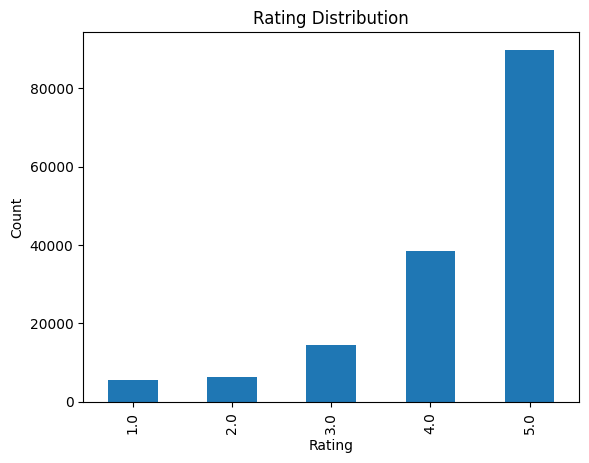

In [15]:
import matplotlib.pyplot as plt

# Plot rating distribution
df_small["rating"].value_counts().sort_index().plot(kind="bar")
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

Average interactions per user: 30.927185437087417
Max interactions per user: 333
Min interactions per user: 1


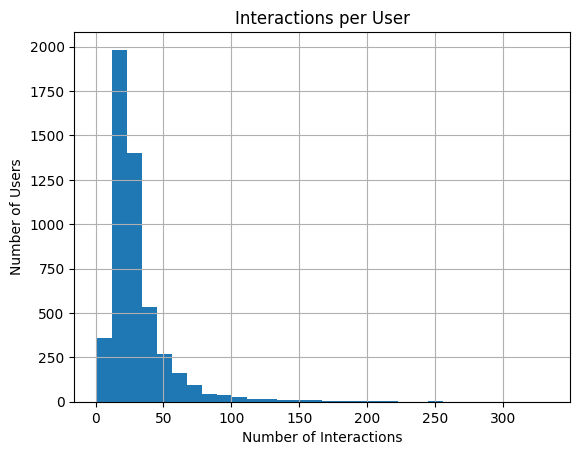

In [16]:
# Count number of interactions per user
user_interactions = df_small.groupby("user_id").size()

print("Average interactions per user:", user_interactions.mean())
print("Max interactions per user:", user_interactions.max())
print("Min interactions per user:", user_interactions.min())

user_interactions.hist(bins=30)
plt.title("Interactions per User")
plt.xlabel("Number of Interactions")
plt.ylabel("Number of Users")
plt.show()

Average interactions per item: 13.706117021276595
Max interactions per item: 431
Min interactions per item: 5


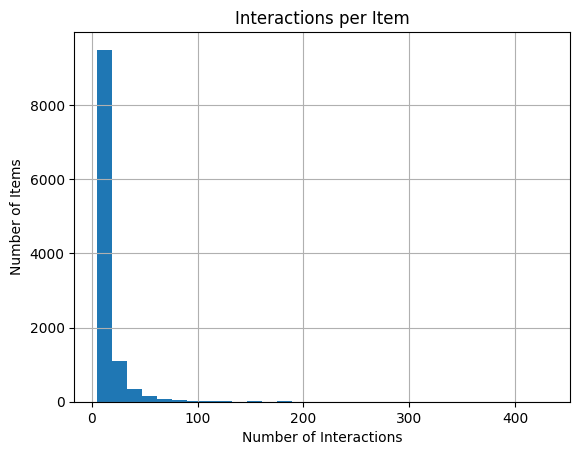

In [17]:
# Count number of interactions per item
item_interactions = df_small.groupby("item_id").size()

print("Average interactions per item:", item_interactions.mean())
print("Max interactions per item:", item_interactions.max())
print("Min interactions per item:", item_interactions.min())

item_interactions.hist(bins=30)
plt.title("Interactions per Item")
plt.xlabel("Number of Interactions")
plt.ylabel("Number of Items")
plt.show()

In [18]:
# Convert timestamp and sort interactions chronologically

df_eda = df_small.copy()

df_eda["timestamp"] = pd.to_datetime(df_eda["timestamp"], unit="s")
df_small = df_small.sort_values(["user_id", "timestamp"])

In [19]:

# Build user interaction sequences
user_sequences = df_small.groupby("user_id")["item_id"].apply(list)

# Keep users with sufficient interaction history
user_sequences = user_sequences[user_sequences.apply(len) >= 5]

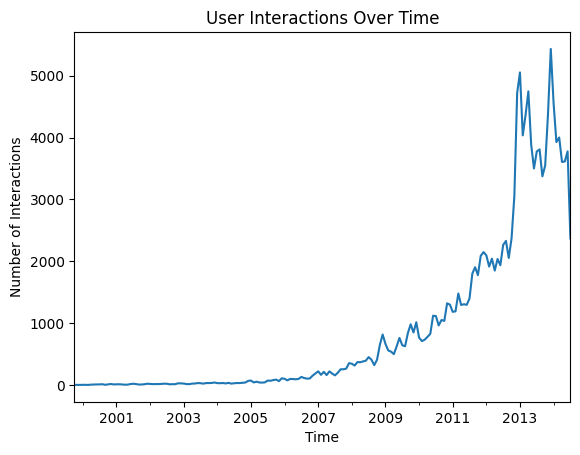

In [20]:
# Create a copy for time-based EDA only
df_eda = df_small.copy()

# Convert timestamp to datetime only in the EDA copy
df_eda["timestamp"] = pd.to_datetime(df_eda["timestamp"], unit="s")

# Plot interactions over time
df_eda.set_index("timestamp").resample("ME").size().plot()

plt.title("User Interactions Over Time")
plt.xlabel("Time")
plt.ylabel("Number of Interactions")
plt.show()

In [21]:
# Calculate dataset sparsity (after filtering)
num_users = df_small["user_id"].nunique()
num_items = df_small["item_id"].nunique()
num_interactions = len(df_small)

sparsity = 1 - (num_interactions / (num_users * num_items))
print("Sparsity:", sparsity)

Sparsity: 0.997258228241393


In [22]:
# Top 5 popular items (optional insight)
print(df_small["item_id"].value_counts().head(5))

item_id
B007WTAJTO    431
B003ES5ZUU    389
B0088CJT4U    340
B002WE6D44    262
B000N99BBC    261
Name: count, dtype: int64


In [23]:
k = 5

user_counts = df_small['user_id'].value_counts()
item_counts = df_small['item_id'].value_counts()

df_small = df_small[df_small['user_id'].isin(user_counts[user_counts >= k].index)]
df_small = df_small[df_small['item_id'].isin(item_counts[item_counts >= k].index)]

df_small = df_small.sort_values(['user_id', 'timestamp']).reset_index(drop=True)

print("Subset shape after filtering:", df_small.shape)
print("Users:", df_small['user_id'].nunique())
print("Items:", df_small['item_id'].nunique())

Subset shape after filtering: (154552, 4)
Users: 4978
Items: 11280


# **Preprocessing**

In [24]:
# Drop missing values
df_raw = df_raw.dropna().copy()

# Convert columns to proper types
df_raw['user_id'] = df_raw['user_id'].astype(str)
df_raw['item_id'] = df_raw['item_id'].astype(str)
df_raw['rating'] = pd.to_numeric(df_raw['rating'], errors='coerce')
df_raw['timestamp'] = pd.to_numeric(df_raw['timestamp'], errors='coerce')

# Drop rows that became invalid after conversion
df_raw = df_raw.dropna().copy()

print("Cleaned raw shape:", df_raw.shape)
df_raw.head()

Cleaned raw shape: (7824482, 4)


,user_id,item_id,rating,timestamp
0,AKM1MP6P0OYPR,0132793040,5.0,1365811200
1,A2CX7LUOHB2NDG,0321732944,5.0,1341100800
2,A2NWSAGRHCP8N5,0439886341,1.0,1367193600
3,A2WNBOD3WNDNKT,0439886341,3.0,1374451200
4,A1GI0U4ZRJA8WN,0439886341,1.0,1334707200


In [25]:
# Sort by user and time to preserve sequential order
df_raw = df_raw.sort_values(['user_id', 'timestamp']).reset_index(drop=True)

print("Sorted raw shape:", df_raw.shape)
df_raw.head()

Sorted raw shape: (7824482, 4)


,user_id,item_id,rating,timestamp
0,A00000262KYZUE4J55XGL,B003UYU16G,5.0,1353456000
1,A000063614T1OE0BUSKUT,B00419ZT3E,5.0,1365120000
2,A000063614T1OE0BUSKUT,B00432ZSHG,5.0,1365120000
3,A00009182QVLSWIGHLS1B,B009SXR7WE,5.0,1364947200
4,A00009661LC9LQPGKJ24G,B004GWQBWY,5.0,1351209600


# **Save as RecBole .inter**

In [26]:
import os

os.makedirs('dataset/amazon-electronics-small', exist_ok=True)

inter_path = 'dataset/amazon-electronics-small/amazon-electronics-small.inter'

with open(inter_path, 'w') as f:
    f.write('user_id:token\titem_id:token\trating:float\ttimestamp:float\n')
    df_small[['user_id', 'item_id', 'rating', 'timestamp']].to_csv(
        f,
        sep='\t',
        header=False,
        index=False
    )

print("Saved to:", inter_path)

Saved to: dataset/amazon-electronics-small/amazon-electronics-small.inter


In [27]:
!head dataset/amazon-electronics-small/amazon-electronics-small.inter

user_id:token	item_id:token	rating:float	timestamp:float
A100UD67AHFODS	B0001D3K8A	5.0	1150588800
A100UD67AHFODS	B0002SQ2P2	5.0	1150588800
A100UD67AHFODS	B001FVMQEQ	1.0	1244592000
A100UD67AHFODS	B004MYFTD8	1.0	1335744000
A100UD67AHFODS	B000U0S304	5.0	1349568000
A100UD67AHFODS	B006SOLITY	4.0	1349654400
A100UD67AHFODS	B005CLPP8E	5.0	1349740800
A100UD67AHFODS	B009H8JOZS	5.0	1349827200
A100UD67AHFODS	B00746LVOM	4.0	1349913600


In [28]:
import pandas as pd

check_df = pd.read_csv(
    'dataset/amazon-electronics-small/amazon-electronics-small.inter',
    sep='\t'
)

print("Saved dataset shape:", check_df.shape)
check_df.head()

Saved dataset shape: (154552, 4)


,user_id:token,item_id:token,rating:float,timestamp:float
0,A100UD67AHFODS,B0001D3K8A,5.0,1150588800
1,A100UD67AHFODS,B0002SQ2P2,5.0,1150588800
2,A100UD67AHFODS,B001FVMQEQ,1.0,1244592000
3,A100UD67AHFODS,B004MYFTD8,1.0,1335744000
4,A100UD67AHFODS,B000U0S304,5.0,1349568000


# **Dataset config**

In [29]:
%%writefile config/amazon-electronics-small.yaml
# general
dataset: amazon-electronics-small
gpu_id: 0
use_gpu: True
seed: 42
state: INFO
reproducibility: True
data_path: 'dataset/'
checkpoint_dir: 'saved'
show_progress: True
save_dataset: False
save_dataloaders: False

# dataset
load_col:
    inter: [user_id, item_id, rating, timestamp]

MAX_ITEM_LIST_LENGTH: 50
USER_ID_FIELD: user_id
ITEM_ID_FIELD: item_id
RATING_FIELD: rating
TIME_FIELD: timestamp

# Filtering
rm_dup_inter: "first"
val_interval: ~
filter_inter_by_user_or_item: True
user_inter_num_interval: "[5,inf)"
item_inter_num_interval: "[5,inf)"

# model hyperparameters
n_layers: 3
n_heads: 4
hidden_size: 64
inner_size: 128
hidden_dropout_prob: 0.5
attn_dropout_prob: 0.5
hidden_act: 'gelu'
layer_norm_eps: 1e-12
initializer_range: 0.02
loss_type: 'CE'

# AC settings
two_level: True
rich_calibrated_combine: 'none'
trainable_mask_loss_weight: False
mask_loss_weight: 0.03
combine_option: 'gate'
use_position_embedding: False
use_order: True
use_distance: True

Writing config/amazon-electronics-small.yaml


In [30]:
!cat config/amazon-electronics-small.yaml

# general
dataset: amazon-electronics-small
gpu_id: 0
use_gpu: True
seed: 42
state: INFO
reproducibility: True
data_path: 'dataset/'
checkpoint_dir: 'saved'
show_progress: True
save_dataset: False
save_dataloaders: False

# dataset
load_col:
    inter: [user_id, item_id, rating, timestamp]

MAX_ITEM_LIST_LENGTH: 50
USER_ID_FIELD: user_id
ITEM_ID_FIELD: item_id
RATING_FIELD: rating
TIME_FIELD: timestamp

# Filtering
rm_dup_inter: "first"
val_interval: ~
filter_inter_by_user_or_item: True
user_inter_num_interval: "[5,inf)"
item_inter_num_interval: "[5,inf)"

# model hyperparameters
n_layers: 3
n_heads: 4
hidden_size: 64
inner_size: 128
hidden_dropout_prob: 0.5
attn_dropout_prob: 0.5
hidden_act: 'gelu'
layer_norm_eps: 1e-12
initializer_range: 0.02
loss_type: 'CE'

# AC settings
two_level: True
rich_calibrated_combine: 'none'
trainable_mask_loss_weight: False
mask_loss_weight: 0.03
combine_option: 'gate'
use_position_embedding: False
use_order: True
use_distance: True


# **Small training config for 5 epochs**

In [31]:
%%writefile config/config_t_small.yaml
epochs: 5
train_batch_size: 256
learner: adam
learning_rate: 0.0001
eval_step: 1
stopping_step: 5

metrics: ["Recall", "Hit", "MRR", "NDCG"]

topk: [10, 20]

valid_metric: Recall@10

eval_batch_size: 256
neg_sampling: ~

Writing config/config_t_small.yaml


In [32]:
!cat config/config_t_small.yaml

epochs: 5
train_batch_size: 256
learner: adam
learning_rate: 0.0001
eval_step: 1
stopping_step: 5

metrics: ["Recall", "Hit", "MRR", "NDCG"]

topk: [10, 20]

valid_metric: Recall@10

eval_batch_size: 256
neg_sampling: ~


# **Patch NumPy compatibility bug**

In [33]:
!sed -i 's/np.float/float/g' recbole/evaluator/metrics.py

In [34]:
!grep -n "np.float\|dtype=float" recbole/evaluator/metrics.py

90:        result = np.zeros_like(pos_index, dtype=float)
131:        result = np.zeros_like(pos_index, dtype=float)
190:        iranks = np.zeros_like(pos_index, dtype=float)
196:        ranks = np.zeros_like(pos_index, dtype=float)


# **Run baseline SASRec**

In [35]:
!cat config/config_t_small.yaml

epochs: 5
train_batch_size: 256
learner: adam
learning_rate: 0.0001
eval_step: 1
stopping_step: 5

metrics: ["Recall", "Hit", "MRR", "NDCG"]

topk: [10, 20]

valid_metric: Recall@10

eval_batch_size: 256
neg_sampling: ~


In [36]:
!grep -n "_add_hparam_to_tensorboard" recbole/trainer/trainer.py

287:    def _add_hparam_to_tensorboard(self, best_valid_result):
390:        self._add_hparam_to_tensorboard(self.best_valid_score)
786:    def _add_hparam_to_tensorboard(self, best_valid_result):
923:        self._add_hparam_to_tensorboard(self.best_valid_score)
1688:        self._add_hparam_to_tensorboard(self.best_valid_score)


In [37]:
!sed -i 's/self._add_hparam_to_tensorboard(self.best_valid_score)/# self._add_hparam_to_tensorboard(self.best_valid_score)/g' recbole/trainer/trainer.py

In [38]:
!grep -n "_add_hparam_to_tensorboard" recbole/trainer/trainer.py

287:    def _add_hparam_to_tensorboard(self, best_valid_result):
390:        # self._add_hparam_to_tensorboard(self.best_valid_score)
786:    def _add_hparam_to_tensorboard(self, best_valid_result):
923:        # self._add_hparam_to_tensorboard(self.best_valid_score)
1688:        # self._add_hparam_to_tensorboard(self.best_valid_score)


In [39]:
import torch
from recbole.config.configurator import Config

torch.serialization.add_safe_globals([Config])

In [40]:
!sed -i "s/checkpoint = torch.load(checkpoint_file)/checkpoint = torch.load(checkpoint_file, weights_only=False)/g" recbole/trainer/trainer.py

In [41]:

!python run_recbole.py --model=SASRec --dataset=amazon-electronics-small --epochs=10 --config_files="config/amazon-electronics-small.yaml config/config_t_small.yaml"

2026-05-15 11:52:45.929865: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-15 11:52:45.999342: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/content/AC-TSR/AC-TSR/recbole/model/sequential_recommender/dien.py:312: SyntaxWarning: invalid escape sequence '\p'
  ..math: {h}_{t}^{\prime}=\left(1-a_{t}\right) * {h}_{t-1}^{\prime}+a_{t} * \tilde{{h}}_{t}^{\prime}
/content/AC-TSR/AC-TSR/recbole/model/sequential_recommender/dien.py:356: SyntaxWarning: invalid escape sequence '\p'
  ..math: \tilde{{u}}_{t}^{\prime}=a_{

In [42]:
import torch
from recbole.config.configurator import Config

torch.serialization.add_safe_globals([Config])

# **Run baseline AC-SASRec**

In [43]:
!python run_recbole.py --model=ACSASRec --dataset=amazon-electronics-small --epochs=5 --config_files="config/amazon-electronics-small.yaml config/config_t_small.yaml"

2026-05-15 11:58:11.295757: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-15 11:58:11.365502: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
15 May 11:58    INFO  
General Hyper Parameters:
gpu_id = 0
use_gpu = True
seed = 42
state = INFO
reproducibility = True
data_path = dataset/amazon-electronics-small
checkpoint_dir = saved
show_progress = True
save_dataset = False
dataset_save_path = None
save_dataloaders = False
dataloaders_save_path = None
log_wandb = False

Training Hyper Parameters:
epochs = 5
train_b

In [44]:
!ls saved

ACSASRec-May-15-2026_11-58-18.pth  SASRec-May-15-2026_11-52-53.pth


In [ ]:
"""
from google.colab import files

files.download('saved/ACSASRec-May-12-2026_10-49-28.pth')
"""

FileNotFoundError: Cannot find file: saved/ACSASRec-May-12-2026_10-49-28.pth

# Create Baseline Comparison Results Table

In [45]:
baseline_results = pd.DataFrame({
    "Metric": [
        "Recall@10", "Recall@20",
        "Hit@10", "Hit@20",
        "MRR@10", "MRR@20",
        "NDCG@10", "NDCG@20"
    ],

    "SASRec": [
        0.0277, 0.0420,
        0.0277, 0.0420,
        0.0120, 0.0129,
        0.0156, 0.0192
    ],

    "AC-SASRec": [
        0.0301, 0.0442,
        0.0301, 0.0442,
        0.0131, 0.0141,
        0.0171, 0.0206
    ]
})

baseline_results["Improvement (%)"] = (
    (baseline_results["AC-SASRec"] - baseline_results["SASRec"])
    / baseline_results["SASRec"] * 100
).round(2)

display(baseline_results)

,Metric,SASRec,AC-SASRec,Improvement (%)
0,Recall@10,0.0277,0.0301,8.66
1,Recall@20,0.0420,0.0442,5.24
2,Hit@10,0.0277,0.0301,8.66
3,Hit@20,0.0420,0.0442,5.24
4,MRR@10,0.0120,0.0131,9.17
5,MRR@20,0.0129,0.0141,9.30
6,NDCG@10,0.0156,0.0171,9.62
7,NDCG@20,0.0192,0.0206,7.29


# Save Baseline Comparison Results

In [46]:
baseline_results.to_csv("baseline_sasrec_vs_acsasrec_test_results.csv", index=False)

# Plot SASRec vs AC-SASRec Test Performance

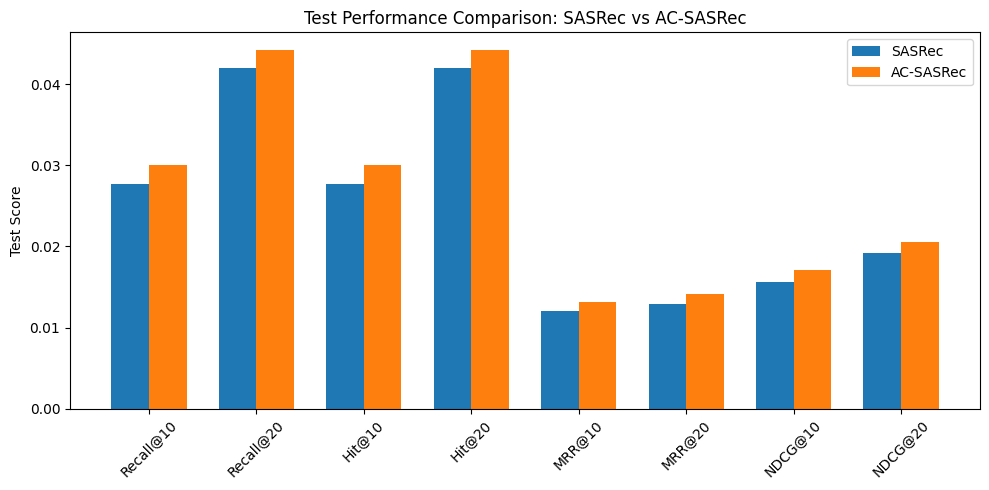

In [47]:
import numpy as np
import matplotlib.pyplot as plt

metrics = baseline_results["Metric"]
x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(10,5))
plt.bar(x - width/2, baseline_results["SASRec"], width, label="SASRec")
plt.bar(x + width/2, baseline_results["AC-SASRec"], width, label="AC-SASRec")

plt.xticks(x, metrics, rotation=45)
plt.ylabel("Test Score")
plt.title("Test Performance Comparison: SASRec vs AC-SASRec")
plt.legend()
plt.tight_layout()
plt.show()

# Compare Runtime and GPU Memory Usage

In [ ]:
"""runtime_df = pd.DataFrame({
    "Model": ["SASRec", "AC-SASRec"],
    "Time per Epoch (sec)": [83, 720],
    "GPU RAM Usage (GB)": [0.45, 3.24]
})

display(runtime_df)"""

,Model,Time per Epoch (sec),GPU RAM Usage (GB)
0,SASRec,83,0.45
1,AC-SASRec,720,3.24


# Real User Sequence Example


In [ ]:
"""# ==============================
# Real User Sequence Example
# ==============================

example_user = df_small['user_id'].value_counts().index[0]

user_sequence = df_small[
    df_small['user_id'] == example_user
].sort_values('timestamp')

print("Example User:", example_user)

display(
    user_sequence[
        ['user_id', 'item_id', 'rating', 'timestamp']
    ].tail(10)
)"""

Example User: ADLVFFE4VBT8


,user_id,item_id,rating,timestamp
128807,ADLVFFE4VBT8,B00IF0KJTE,4.0,1401062400
128809,ADLVFFE4VBT8,B00JP12170,4.0,1401148800
128808,ADLVFFE4VBT8,B00HQ883T4,5.0,1401148800
128810,ADLVFFE4VBT8,B00JP7R7DC,4.0,1401148800
128811,ADLVFFE4VBT8,B00CDIK908,5.0,1401321600
128812,ADLVFFE4VBT8,B00ETBHOIM,4.0,1401667200
128813,ADLVFFE4VBT8,B003UE52ME,5.0,1402444800
128814,ADLVFFE4VBT8,B00EZJQY0C,4.0,1402617600
128815,ADLVFFE4VBT8,B00L3YHF6O,5.0,1404518400
128816,ADLVFFE4VBT8,B00HLDFUM2,4.0,1405036800


# Ablation study

In [48]:
# Use the same filtered dataset used in the baseline experiments.
# This ensures that all ablation experiments are compared fairly.
df_ablation = df_small.copy()

# Sort interactions by user and timestamp to preserve sequential order.
df_ablation = df_ablation.sort_values(['user_id', 'timestamp']).reset_index(drop=True)

print("Ablation dataset shape:", df_ablation.shape)
print("Number of users:", df_ablation['user_id'].nunique())
print("Number of items:", df_ablation['item_id'].nunique())
print("Number of interactions:", len(df_ablation))

Ablation dataset shape: (154552, 4)
Number of users: 4978
Number of items: 11280
Number of interactions: 154552


In [49]:
# ============================================================
# Save Ablation Dataset in RecBole Format
# ============================================================

import os

# Create dataset folder
os.makedirs('dataset/amazon-electronics-ablation', exist_ok=True)

# Define interaction file path
inter_path = 'dataset/amazon-electronics-ablation/amazon-electronics-ablation.inter'

# Save the dataset using RecBole .inter format
with open(inter_path, 'w') as f:
    f.write('user_id:token\titem_id:token\trating:float\ttimestamp:float\n')
    df_ablation[['user_id', 'item_id', 'rating', 'timestamp']].to_csv(
        f,
        sep='\t',
        header=False,
        index=False
    )

print("Saved ablation dataset to:", inter_path)

# Verify saved file
!head dataset/amazon-electronics-ablation/amazon-electronics-ablation.inter

Saved ablation dataset to: dataset/amazon-electronics-ablation/amazon-electronics-ablation.inter
user_id:token	item_id:token	rating:float	timestamp:float
A100UD67AHFODS	B0001D3K8A	5.0	1150588800
A100UD67AHFODS	B0002SQ2P2	5.0	1150588800
A100UD67AHFODS	B001FVMQEQ	1.0	1244592000
A100UD67AHFODS	B004MYFTD8	1.0	1335744000
A100UD67AHFODS	B000U0S304	5.0	1349568000
A100UD67AHFODS	B006SOLITY	4.0	1349654400
A100UD67AHFODS	B005CLPP8E	5.0	1349740800
A100UD67AHFODS	B009H8JOZS	5.0	1349827200
A100UD67AHFODS	B00746LVOM	4.0	1349913600


In [50]:
# ============================================================
# Common Training Configuration for All Ablation Experiments
# ============================================================

%%writefile config/config_ablation.yaml
epochs: 5
train_batch_size: 256
learner: adam
learning_rate: 0.0001
neg_sampling: ~

eval_step: 1
stopping_step: 3

metrics: ["Recall", "Hit", "MRR", "NDCG"]
topk: [10, 20]
valid_metric: Recall@10

eval_batch_size: 256

Writing config/config_ablation.yaml


In [51]:
# ============================================================
# Compatibility Fixes
# ============================================================

# Fix deprecated NumPy type issue.
!sed -i 's/np.float/float/g' recbole/evaluator/metrics.py

# Disable TensorBoard hyperparameter logging if it causes errors.
!sed -i 's/self._add_hparam_to_tensorboard(self.best_valid_score)/# self._add_hparam_to_tensorboard(self.best_valid_score)/g' recbole/trainer/trainer.py

# Allow loading RecBole Config safely in PyTorch.
import torch
from recbole.config.configurator import Config

torch.serialization.add_safe_globals([Config])

# Fix PyTorch checkpoint loading issue.
!sed -i "s/checkpoint = torch.load(checkpoint_file)/checkpoint = torch.load(checkpoint_file, weights_only=False)/g" recbole/trainer/trainer.py

### **Full AC**

In [56]:
# ============================================================
# Order = ON, Distance = ON, Adversarial = ON
# ============================================================

# The Full AC model corresponds to the baseline ACSASRec
# experiment trained previously.
# Therefore, the baseline AC-SASRec results are reused here
# without retraining.

### **No Order**

In [55]:
# ============================================================
# Order = OFF, Distance = ON, Adversarial = ON
# ============================================================

%%writefile config/amazon-electronics-ablation-no-order.yaml
dataset: amazon-electronics-ablation
gpu_id: 0
use_gpu: True
seed: 42
state: INFO
reproducibility: True
data_path: 'dataset/'
checkpoint_dir: 'saved'
show_progress: True
save_dataset: False
save_dataloaders: False

load_col:
    inter: [user_id, item_id, rating, timestamp]

MAX_ITEM_LIST_LENGTH: 50
USER_ID_FIELD: user_id
ITEM_ID_FIELD: item_id
RATING_FIELD: rating
TIME_FIELD: timestamp

rm_dup_inter: "first"
filter_inter_by_user_or_item: True
user_inter_num_interval: "[5,inf)"
item_inter_num_interval: "[5,inf)"

n_layers: 3
n_heads: 4
hidden_size: 64
inner_size: 128
hidden_dropout_prob: 0.5
attn_dropout_prob: 0.5
hidden_act: 'gelu'
layer_norm_eps: 1e-12
initializer_range: 0.02
loss_type: 'CE'

# Ablation settings
# Order information is disabled to test its contribution.
two_level: True
rich_calibrated_combine: 'none'
trainable_mask_loss_weight: False
mask_loss_weight: 0.03
combine_option: 'gate'
use_position_embedding: False
use_order: False
use_distance: True

Writing config/amazon-electronics-ablation-no-order.yaml


In [57]:
# Run Experiment 2: No Order
!python run_recbole.py --model=ACSASRec --dataset=amazon-electronics-ablation --config_files="config/amazon-electronics-ablation-no-order.yaml config/config_ablation.yaml"

2026-05-15 13:03:05.591379: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-15 13:03:05.660767: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
15 May 13:03    INFO  
General Hyper Parameters:
gpu_id = 0
use_gpu = True
seed = 42
state = INFO
reproducibility = True
data_path = dataset/amazon-electronics-ablation
checkpoint_dir = saved
show_progress = True
save_dataset = False
dataset_save_path = None
save_dataloaders = False
dataloaders_save_path = None
log_wandb = False

Training Hyper Parameters:
epochs = 5
trai

### **No Distance**

In [58]:
# ============================================================
# Order = ON, Distance = OFF, Adversarial = ON
# ============================================================

%%writefile config/amazon-electronics-ablation-no-distance.yaml
dataset: amazon-electronics-ablation
gpu_id: 0
use_gpu: True
seed: 42
state: INFO
reproducibility: True
data_path: 'dataset/'
checkpoint_dir: 'saved'
show_progress: True
save_dataset: False
save_dataloaders: False

load_col:
    inter: [user_id, item_id, rating, timestamp]

MAX_ITEM_LIST_LENGTH: 50
USER_ID_FIELD: user_id
ITEM_ID_FIELD: item_id
RATING_FIELD: rating
TIME_FIELD: timestamp

rm_dup_inter: "first"
filter_inter_by_user_or_item: True
user_inter_num_interval: "[5,inf)"
item_inter_num_interval: "[5,inf)"

n_layers: 3
n_heads: 4
hidden_size: 64
inner_size: 128
hidden_dropout_prob: 0.5
attn_dropout_prob: 0.5
hidden_act: 'gelu'
layer_norm_eps: 1e-12
initializer_range: 0.02
loss_type: 'CE'

# Ablation settings
# Distance information is disabled to test its contribution.
two_level: True
rich_calibrated_combine: 'none'
trainable_mask_loss_weight: False
mask_loss_weight: 0.03
combine_option: 'gate'
use_position_embedding: False
use_order: True
use_distance: False

Writing config/amazon-electronics-ablation-no-distance.yaml


In [59]:
# Run Experiment 3: No Distance
!python run_recbole.py --model=ACSASRec --dataset=amazon-electronics-ablation --config_files="config/amazon-electronics-ablation-no-distance.yaml config/config_ablation.yaml"

2026-05-15 13:23:12.474767: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-15 13:23:12.544355: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
15 May 13:23    INFO  
General Hyper Parameters:
gpu_id = 0
use_gpu = True
seed = 42
state = INFO
reproducibility = True
data_path = dataset/amazon-electronics-ablation
checkpoint_dir = saved
show_progress = True
save_dataset = False
dataset_save_path = None
save_dataloaders = False
dataloaders_save_path = None
log_wandb = False

Training Hyper Parameters:
epochs = 5
trai

### **No Adversarial**

In [62]:
# ============================================================
# Order = ON, Distance = ON, Adversarial Loss = OFF
# ============================================================

%%writefile config/amazon-electronics-ablation-no-adversarial.yaml
dataset: amazon-electronics-ablation
gpu_id: 0
use_gpu: True
seed: 42
state: INFO
reproducibility: True
data_path: 'dataset/'
checkpoint_dir: 'saved'
show_progress: True
save_dataset: False
save_dataloaders: False

load_col:
    inter: [user_id, item_id, rating, timestamp]

MAX_ITEM_LIST_LENGTH: 50
USER_ID_FIELD: user_id
ITEM_ID_FIELD: item_id
RATING_FIELD: rating
TIME_FIELD: timestamp

rm_dup_inter: "first"
filter_inter_by_user_or_item: True
user_inter_num_interval: "[5,inf)"
item_inter_num_interval: "[5,inf)"

n_layers: 3
n_heads: 4
hidden_size: 64
inner_size: 128
hidden_dropout_prob: 0.5
attn_dropout_prob: 0.5
hidden_act: 'gelu'
layer_norm_eps: 1e-12
initializer_range: 0.02
loss_type: 'CE'

# Spatial calibration is enabled.
use_position_embedding: False
use_order: True
use_distance: True

# Keep two_level enabled to avoid implementation errors.
two_level: True

# Disable the adversarial loss contribution.
mask_loss_weight: 0.0
trainable_mask_loss_weight: False

rich_calibrated_combine: 'none'
combine_option: 'gate'

Overwriting config/amazon-electronics-ablation-no-adversarial.yaml


In [63]:
# Run Experiment 4: No Adversarial
!python run_recbole.py --model=ACSASRec --dataset=amazon-electronics-ablation --config_files="config/amazon-electronics-ablation-no-adversarial.yaml config/config_ablation.yaml"

2026-05-15 13:43:16.378620: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-15 13:43:16.448402: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
15 May 13:43    INFO  
General Hyper Parameters:
gpu_id = 0
use_gpu = True
seed = 42
state = INFO
reproducibility = True
data_path = dataset/amazon-electronics-ablation
checkpoint_dir = saved
show_progress = True
save_dataset = False
dataset_save_path = None
save_dataloaders = False
dataloaders_save_path = None
log_wandb = False

Training Hyper Parameters:
epochs = 5
trai

## Ablation Study Results Table

In [64]:
import pandas as pd

ablation_results = pd.DataFrame({
    "Experiment": [
        "Full AC",
        "No Order",
        "No Distance",
        "No Adversarial"
    ],

    "Recall@10": [
        0.0301,
        0.0245,
        0.0215,
        0.0253
    ],

    "Recall@20": [
        0.0442,
        0.0342,
        0.0344,
        0.0358
    ],

    "Hit@10": [
        0.0301,
        0.0245,
        0.0215,
        0.0253
    ],

    "Hit@20": [
        0.0442,
        0.0342,
        0.0344,
        0.0358
    ],

    "MRR@10": [
        0.0131,
        0.0095,
        0.0096,
        0.0091
    ],

    "MRR@20": [
        0.0141,
        0.0102,
        0.0105,
        0.0098
    ],

    "NDCG@10": [
        0.0171,
        0.0130,
        0.0124,
        0.0128
    ],

    "NDCG@20": [
        0.0206,
        0.0154,
        0.0157,
        0.0154
    ]
})

display(ablation_results)

,Experiment,Recall@10,Recall@20,Hit@10,Hit@20,MRR@10,MRR@20,NDCG@10,NDCG@20
0,Full AC,0.0301,0.0442,0.0301,0.0442,0.0131,0.0141,0.0171,0.0206
1,No Order,0.0245,0.0342,0.0245,0.0342,0.0095,0.0102,0.0130,0.0154
2,No Distance,0.0215,0.0344,0.0215,0.0344,0.0096,0.0105,0.0124,0.0157
3,No Adversarial,0.0253,0.0358,0.0253,0.0358,0.0091,0.0098,0.0128,0.0154


# Define Helper Functions

In [65]:
# ==============================
# Helper Function: Run RecBole and Capture Output
# ==============================

import subprocess
import re
import pandas as pd
import matplotlib.pyplot as plt
import os

def run_recbole_capture(model_name, dataset_name, config_files):
    command = f'python run_recbole.py --model={model_name} --dataset={dataset_name} --config_files="{config_files}"'

    result = subprocess.run(
        command,
        shell=True,
        capture_output=True,
        text=True
    )

    output = result.stdout + "\n" + result.stderr
    print(output)

    return output

# Function to Extract Final Evaluation Metrics

In [66]:
# ==============================
# Extract Final Metrics from RecBole Output
# ==============================

def extract_final_metrics(output):
    metrics = {}

    pattern = r"'([^']+)':\s*([0-9.]+)"
    matches = re.findall(pattern, output)

    for metric, value in matches:
        metrics[metric] = float(value)

    return metrics

# Hyperparameter Tuning for AC-SASRec

In [67]:
# ==============================
# Hyperparameter Tuning for AC-SASRec
# ==============================

tuning_results = []

experiments = [
    {
        "Experiment": "AC_lr_0.0001_dropout_0.5_hidden64",
        "learning_rate": 0.0001,
        "hidden_dropout_prob": 0.5,
        "attn_dropout_prob": 0.5,
        "hidden_size": 64
    },
    {
        "Experiment": "AC_lr_0.0005_dropout_0.5_hidden64",
        "learning_rate": 0.0005,
        "hidden_dropout_prob": 0.5,
        "attn_dropout_prob": 0.5,
        "hidden_size": 64
    },
    {
        "Experiment": "AC_lr_0.0001_dropout_0.3_hidden64",
        "learning_rate": 0.0001,
        "hidden_dropout_prob": 0.3,
        "attn_dropout_prob": 0.3,
        "hidden_size": 64
    },
    {
        "Experiment": "AC_lr_0.0001_dropout_0.5_hidden128",
        "learning_rate": 0.0001,
        "hidden_dropout_prob": 0.5,
        "attn_dropout_prob": 0.5,
        "hidden_size": 128
    }
]

In [68]:
for exp in experiments:

    config_name = f"config/{exp['Experiment']}.yaml"

    config_text = f"""
dataset: amazon-electronics-small
gpu_id: 0
use_gpu: True
seed: 42
state: INFO
reproducibility: True
data_path: 'dataset/'
checkpoint_dir: 'saved'
show_progress: True
save_dataset: False
save_dataloaders: False

load_col:
    inter: [user_id, item_id, rating, timestamp]

MAX_ITEM_LIST_LENGTH: 50
USER_ID_FIELD: user_id
ITEM_ID_FIELD: item_id
RATING_FIELD: rating
TIME_FIELD: timestamp

rm_dup_inter: "first"
filter_inter_by_user_or_item: True
user_inter_num_interval: "[5,inf)"
item_inter_num_interval: "[5,inf)"

n_layers: 3
n_heads: 4
hidden_size: {exp['hidden_size']}
inner_size: 128
hidden_dropout_prob: {exp['hidden_dropout_prob']}
attn_dropout_prob: {exp['attn_dropout_prob']}
hidden_act: 'gelu'
layer_norm_eps: 1e-12
initializer_range: 0.02
loss_type: 'CE'

two_level: True
rich_calibrated_combine: 'none'
trainable_mask_loss_weight: False
mask_loss_weight: 0.03
combine_option: 'gate'
use_position_embedding: False
use_order: True
use_distance: True
"""

    with open(config_name, "w") as f:
        f.write(config_text)

    train_config = f"""
epochs: 5
train_batch_size: 256
learner: adam
learning_rate: {exp['learning_rate']}
neg_sampling: ~

eval_step: 1
stopping_step: 5

metrics: ["Recall", "Hit", "MRR", "NDCG"]

topk: [10, 20]

valid_metric: Recall@10

eval_batch_size: 256
"""

    train_config_name = f"config/train_{exp['Experiment']}.yaml"

    with open(train_config_name, "w") as f:
        f.write(train_config)

    print("\n==============================")
    print("Running:", exp["Experiment"])
    print("==============================")

    output = run_recbole_capture(
        model_name="ACSASRec",
        dataset_name="amazon-electronics-small",
        config_files=f"{config_name} {train_config_name}"
    )

    metrics = extract_final_metrics(output)

    tuning_results.append({
        "Experiment": exp["Experiment"],
        "learning_rate": exp["learning_rate"],
        "hidden_dropout": exp["hidden_dropout_prob"],
        "attn_dropout": exp["attn_dropout_prob"],
        "hidden_size": exp["hidden_size"],
        **metrics
    })

Streaming output truncated to the last 5000 lines.
Train     5: 100%|███████████████████████| 546/546 [02:46<00:00,  3.29it/s, GPU RAM: 5.57 G/39.49 G]
15 May 15:51    INFO  epoch 5 training [time: 166.01s, train loss: 21091.0648]
15 May 15:51    INFO  epoch 5 training [time: 166.01s, train loss: 4657.3509]

Evaluate   : 100%|█████████████████████████| 20/20 [00:01<00:00, 11.64it/s, GPU RAM: 5.57 G/39.49 G]
15 May 15:51    INFO  epoch 5 evaluating [time: 1.74s, valid_score: 0.023900]
15 May 15:51    INFO  valid result: 
recall@10 : 0.0239    recall@20 : 0.04    hit@10 : 0.0239    hit@20 : 0.04    mrr@10 : 0.0083    mrr@20 : 0.0094    ndcg@10 : 0.0119    ndcg@20 : 0.016
15 May 15:51    INFO  Saving current: saved/ACSASRec-May-15-2026_15-34-53.pth

Train     6: 100%|███████████████████████| 546/546 [02:41<00:00,  3.38it/s, GPU RAM: 5.57 G/39.49 G]
15 May 15:54    INFO  epoch 6 training [time: 161.68s, train loss: 21197.3780]
15 May 15:54    INFO  epoch 6 training [time: 161.68s, train lo

# Create Hyperparameter Tuning Results Table

In [69]:
# Create tuning results dataframe
tuning_df = pd.DataFrame(tuning_results)

# Display tuning results
display(tuning_df)

# Save tuning results to CSV
tuning_df.to_csv("ac_sasrec_tuning_results.csv", index=False)

,Experiment,learning_rate,hidden_dropout,attn_dropout,hidden_size
0,AC_lr_0.0001_dropout_0.5_hidden64,0.0001,0.5,0.5,64
1,AC_lr_0.0005_dropout_0.5_hidden64,0.0005,0.5,0.5,64
2,AC_lr_0.0001_dropout_0.3_hidden64,0.0001,0.3,0.3,64
3,AC_lr_0.0001_dropout_0.5_hidden128,0.0001,0.5,0.5,128


# Select Best Hyperparameter Configuration

In [73]:
best_config = "AC_lr_0.0005_dropout_0.5_hidden64"

best_row = tuning_df[
    tuning_df["Experiment"] == best_config
].iloc[0]

print("Best AC-SASRec Hyperparameters:")
display(best_row)

Best AC-SASRec Hyperparameters:


,1
Experiment,AC_lr_0.0005_dropout_0.5_hidden64
learning_rate,0.0005
hidden_dropout,0.5
attn_dropout,0.5
hidden_size,64


# Run Final Test Using Best Hyperparameters

In [74]:
!grep -n "test_result" recbole/quick_start/quick_start.py

61:    test_result = trainer.evaluate(test_data, load_best_model=saved, show_progress=config['show_progress'])
64:    logger.info(set_color('test result', 'yellow') + f': {test_result}')
70:        'test_result': test_result
92:    test_result = trainer.evaluate(test_data, load_best_model=saved)
98:        'test_result': test_result


# Final Tuned Model

In [75]:
# Run final model using best hyperparameters
best_output = run_recbole_capture(
    model_name="ACSASRec",
    dataset_name="amazon-electronics-small",
    config_files=f"config/{best_config}.yaml config/train_{best_config}.yaml"
)

# Extract final test metrics
test_metrics = extract_final_metrics(best_output)

# Create final test results table
test_df = pd.DataFrame([
    {
        "Model": "Tuned AC-SASRec",
        **test_metrics
    }
])

# Display final test results
display(test_df)


2026-05-15 16:10:25.942506: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-15 16:10:26.016079: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
15 May 16:10    INFO  
General Hyper Parameters:
gpu_id = 0
use_gpu = True
seed = 42
state = INFO
reproducibility = True
data_path = dataset/amazon-electronics-small
checkpoint_dir = saved
show_progress = True
save_dataset = False
dataset_save_path = None
save_dataloaders = False
dataloaders_save_path = None
log_wandb = False

Training Hyper Parameters:
epochs = 5
train_

,Model
0,Tuned AC-SASRec


# Compare AC-SASRec Before and After Hyperparameter Tuning

In [76]:
# Baseline AC-SASRec test metrics before tuning
baseline_ac_metrics = {
    "recall@10": 0.0301,
    "recall@20": 0.0442,
    "hit@10": 0.0301,
    "hit@20": 0.0442,
    "mrr@10": 0.0131,
    "mrr@20": 0.0141,
    "ndcg@10": 0.0171,
    "ndcg@20": 0.0206
}

# Tuned AC-SASRec test metrics after tuning
tuned_ac_metrics = {
    "recall@10": 0.0452,
    "recall@20": 0.0657,
    "hit@10": 0.0452,
    "hit@20": 0.0657,
    "mrr@10": 0.0136,
    "mrr@20": 0.0150,
    "ndcg@10": 0.0210,
    "ndcg@20": 0.0261
}

comparison_tuning = pd.DataFrame([
    {
        "Model": "AC-SASRec Before Tuning",
        **baseline_ac_metrics
    },
    {
        "Model": "AC-SASRec After Tuning",
        **tuned_ac_metrics
    }
])

display(comparison_tuning)

,Model,recall@10,recall@20,hit@10,hit@20,mrr@10,mrr@20,ndcg@10,ndcg@20
0,AC-SASRec Before Tuning,0.0301,0.0442,0.0301,0.0442,0.0131,0.0141,0.0171,0.0206
1,AC-SASRec After Tuning,0.0452,0.0657,0.0452,0.0657,0.0136,0.0150,0.0210,0.0261


# Calculate Improvement After Hyperparameter Tuning

In [77]:
improvement_df = pd.DataFrame({
    "Metric": list(baseline_ac_metrics.keys()),
    "Before Tuning": list(baseline_ac_metrics.values()),
    "After Tuning": list(tuned_ac_metrics.values())
})

improvement_df["Improvement (%)"] = (
    (improvement_df["After Tuning"] - improvement_df["Before Tuning"])
    / improvement_df["Before Tuning"] * 100
).round(2)

display(improvement_df)

,Metric,Before Tuning,After Tuning,Improvement (%)
0,recall@10,0.0301,0.0452,50.17
1,recall@20,0.0442,0.0657,48.64
2,hit@10,0.0301,0.0452,50.17
3,hit@20,0.0442,0.0657,48.64
4,mrr@10,0.0131,0.0136,3.82
5,mrr@20,0.0141,0.0150,6.38
6,ndcg@10,0.0171,0.0210,22.81
7,ndcg@20,0.0206,0.0261,26.70


# Plot Performance Before vs After Hyperparameter Tuning

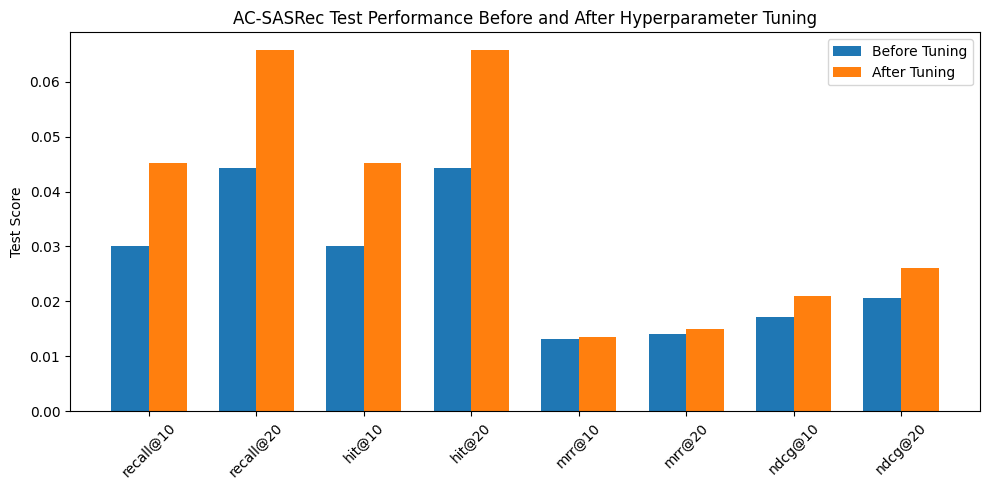

In [78]:
import numpy as np
import matplotlib.pyplot as plt

metrics = improvement_df["Metric"]
x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(10,5))

plt.bar(x - width/2, improvement_df["Before Tuning"], width, label="Before Tuning")
plt.bar(x + width/2, improvement_df["After Tuning"], width, label="After Tuning")

plt.xticks(x, metrics, rotation=45)
plt.ylabel("Test Score")
plt.title("AC-SASRec Test Performance Before and After Hyperparameter Tuning")
plt.legend()
plt.tight_layout()
plt.show()

# Overfitting analysis

In [105]:
# Search for validation loss inside RecBole output
for line in best_output.split("\n"):

    line_lower = line.lower()

    if "valid loss" in line_lower or "validation loss" in line_lower:
        print(line)

In [106]:
import re
import pandas as pd

# Extract clean training loss from RecBole output
def extract_training_loss(output):

    records = []

    for line in output.split("\n"):
        line_lower = line.lower()

        if "epoch" in line_lower and "train loss" in line_lower:
            epoch_match = re.search(r"epoch\s+(\d+)", line_lower)
            loss_match = re.search(r"train loss[: ]+([0-9.]+)", line_lower)

            if epoch_match and loss_match:
                records.append({
                    "Epoch": int(epoch_match.group(1)) + 1,
                    "Train Loss": float(loss_match.group(1))
                })

    loss_df = pd.DataFrame(records)

    # Keep only one loss value per epoch
    loss_df = loss_df.groupby("Epoch", as_index=False).last()

    return loss_df


# Extract validation Recall@10 from RecBole output
def extract_validation_metric(output, metric="recall@10"):

    records = []
    current_epoch = None

    for line in output.split("\n"):
        line_lower = line.lower()

        epoch_match = re.search(r"epoch\s+(\d+)\s+evaluating", line_lower)

        if epoch_match:
            current_epoch = int(epoch_match.group(1)) + 1

        metric_match = re.search(metric + r"\s*:\s*([0-9.]+)", line_lower)

        if metric_match and current_epoch is not None:
            records.append({
                "Epoch": current_epoch,
                metric: float(metric_match.group(1))
            })

    valid_df = pd.DataFrame(records)

    # Keep only one validation value per epoch
    valid_df = valid_df.groupby("Epoch", as_index=False).last()

    return valid_df

In [107]:
# Extract training loss and validation Recall@10
loss_df = extract_training_loss(best_output)

valid_df = extract_validation_metric(
    best_output,
    metric="recall@10"
)

display(loss_df)
display(valid_df)

,Epoch,Train Loss
0,1,4974.9168
1,2,4744.4833
2,3,4506.8395
3,4,4376.5648
4,5,4269.3864
5,6,4180.1296
6,7,4106.9526
7,8,4042.9754
8,9,3990.9238
9,10,3943.5872


,Epoch,recall@10
0,1,0.0187
1,2,0.0265
2,3,0.0337
3,4,0.0348
4,5,0.0406
5,6,0.0416
6,7,0.0422
7,8,0.0426
8,9,0.0450
9,10,0.0424


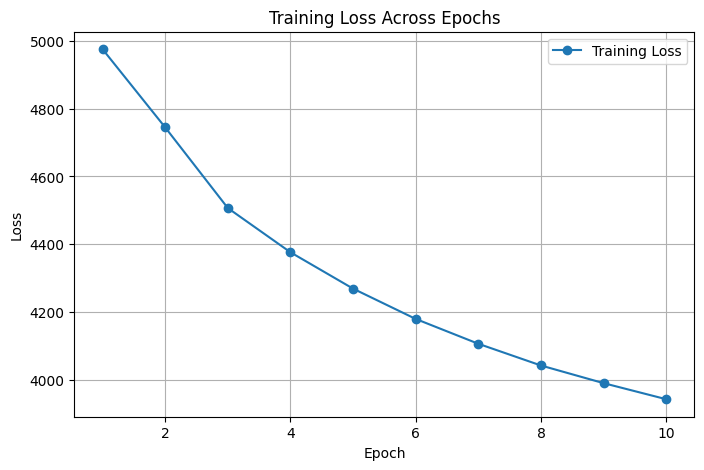

In [108]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    loss_df["Epoch"],
    loss_df["Train Loss"],
    marker="o",
    label="Training Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Across Epochs")
plt.legend()
plt.grid(True)
plt.show()

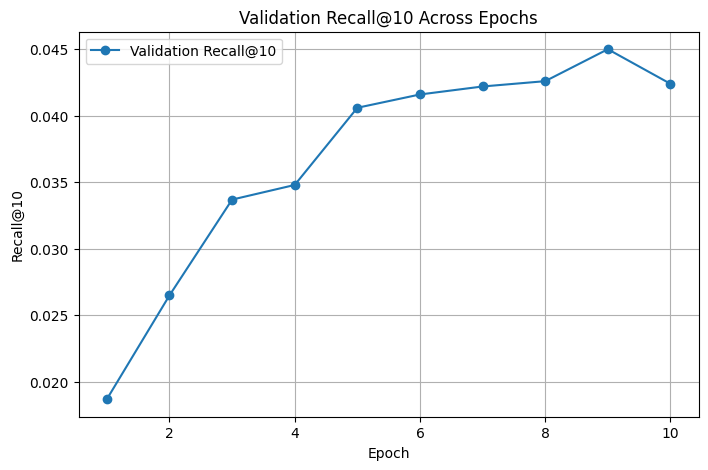

In [109]:
plt.figure(figsize=(8,5))

plt.plot(
    valid_df["Epoch"],
    valid_df["recall@10"],
    marker="o",
    label="Validation Recall@10"
)

plt.xlabel("Epoch")
plt.ylabel("Recall@10")
plt.title("Validation Recall@10 Across Epochs")
plt.legend()
plt.grid(True)
plt.show()

In [110]:
# Find Best Epoch

# Find the best epoch based on Validation Recall@10
best_epoch = valid_df.loc[valid_df["recall@10"].idxmax(), "Epoch"]
best_recall = valid_df["recall@10"].max()

print("Best Epoch:", best_epoch)
print("Best Validation Recall@10:", best_recall)

Best Epoch: 9
Best Validation Recall@10: 0.045


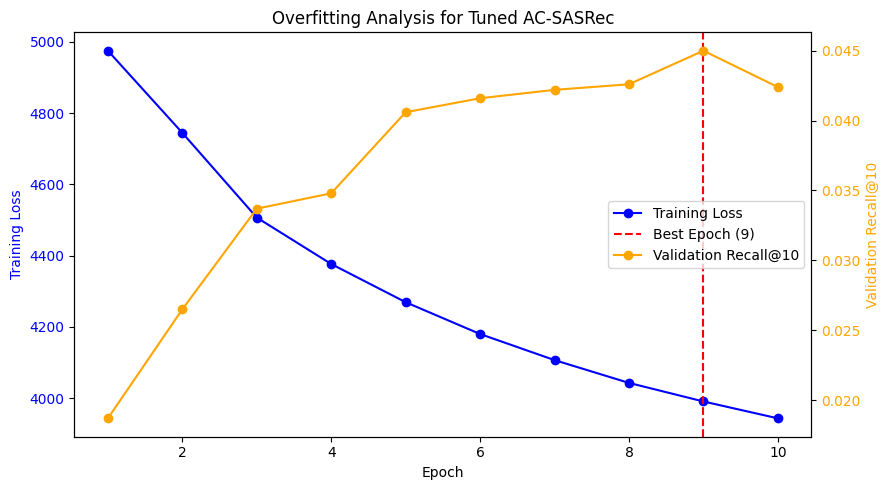

In [111]:
# Combined Overfitting Plot with Best Epoch Line

import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(9,5))

# Plot training loss
ax1.plot(
    loss_df["Epoch"],
    loss_df["Train Loss"],
    marker="o",
    label="Training Loss",
    color="blue"
)

ax1.set_xlabel("Epoch")
ax1.set_ylabel("Training Loss", color="blue")
ax1.tick_params(axis="y", labelcolor="blue")

# Plot validation Recall@10 on second y-axis
ax2 = ax1.twinx()

ax2.plot(
    valid_df["Epoch"],
    valid_df["recall@10"],
    marker="o",
    label="Validation Recall@10",
    color="orange"
)

ax2.set_ylabel("Validation Recall@10", color="orange")
ax2.tick_params(axis="y", labelcolor="orange")

# Add best epoch vertical line
ax1.axvline(
    x=best_epoch,
    color="red",
    linestyle="--",
    label=f"Best Epoch ({best_epoch})"
)

plt.title("Overfitting Analysis for Tuned AC-SASRec")

# Combine legends from both axes
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="center right")

fig.tight_layout()
plt.show()

# **XAI: Similarity-based Explanation**

In [85]:
import os
import glob
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics.pairwise import cosine_similarity
from recbole.quick_start import load_data_and_model

## Find the Latest Trained Checkpoint

In [86]:
# List all saved AC-SASRec checkpoint files
checkpoints = glob.glob("saved/ACSASRec*.pth")

print("Number of checkpoints found:", len(checkpoints))
print("Available checkpoints:")
for ckpt in checkpoints:
    print(ckpt)

# Select the latest checkpoint based on modification time
checkpoint_file = max(checkpoints, key=os.path.getmtime)

print("\nSelected checkpoint for XAI:")
print(checkpoint_file)

Number of checkpoints found: 10
Available checkpoints:
saved/ACSASRec-May-15-2026_16-10-33.pth
saved/ACSASRec-May-15-2026_13-03-12.pth
saved/ACSASRec-May-15-2026_15-09-07.pth
saved/ACSASRec-May-15-2026_12-53-17.pth
saved/ACSASRec-May-15-2026_14-42-51.pth
saved/ACSASRec-May-15-2026_13-23-19.pth
saved/ACSASRec-May-15-2026_11-58-18.pth
saved/ACSASRec-May-15-2026_14-16-56.pth
saved/ACSASRec-May-15-2026_15-34-53.pth
saved/ACSASRec-May-15-2026_13-43-23.pth

Selected checkpoint for XAI:
saved/ACSASRec-May-15-2026_16-10-33.pth


## Load the Tuned AC-SASRec Model

In [87]:
# Save original torch.load
real_torch_load = torch.load

# Create a safe loading wrapper to avoid PyTorch weights_only issues
def safe_load(*args, **kwargs):
    kwargs["weights_only"] = False
    return real_torch_load(*args, **kwargs)

# Temporarily patch torch.load
torch.load = safe_load

# Load model, dataset, and dataloaders from the selected checkpoint
config, model, dataset, train_data, valid_data, test_data = load_data_and_model(
    model_file=checkpoint_file
)

# Restore original torch.load
torch.load = real_torch_load

# Set model to evaluation mode
model.eval()

print("Tuned AC-SASRec model loaded successfully.")
print("Device:", config["device"])

/content/AC-TSR/AC-TSR/recbole/data/dataset/dataset.py:570: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  feat[field].fillna(value=0, inplace=True)
/content/AC-TSR/AC-TSR/recbole/data/dataset/dataset.py:572: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[

Tuned AC-SASRec model loaded successfully.
Device: cuda


## Select a Real User from the Test Data

In [88]:
# Get one batch from the test data
batch = next(iter(test_data))

# RecBole test batch usually returns interaction and history index
interaction = batch[0].to(config["device"])
history_index = batch[1]

print("Test interaction batch loaded.")
print(interaction)

Test interaction batch loaded.
The batch_size of interaction: 256
    user_id, torch.Size([256]), cuda, torch.int64
    item_id, torch.Size([256]), cuda, torch.int64
    rating, torch.Size([256]), cuda, torch.float32
    timestamp, torch.Size([256]), cuda, torch.float32
    item_length, torch.Size([256]), cuda, torch.int64
    item_id_list, torch.Size([256, 50]), cuda, torch.int64
    rating_list, torch.Size([256, 50]), cuda, torch.float32
    timestamp_list, torch.Size([256, 50]), cuda, torch.float32




## Extract the User’s Historical Items

In [89]:
# Get item sequence field name
item_list_field = config["ITEM_ID_FIELD"] + config["LIST_SUFFIX"]

# Get item sequence length field name
item_length_field = config["ITEM_LIST_LENGTH_FIELD"]

# Extract the first user's historical item sequence
history_inner_ids = interaction[item_list_field][0][
    :interaction[item_length_field][0]
].detach().cpu().numpy()

# Remove padding item ID = 0
history_inner_ids = history_inner_ids[history_inner_ids != 0]

# Convert internal item IDs back to original item tokens
history_items = dataset.id2token(
    config["ITEM_ID_FIELD"],
    history_inner_ids
)

print("Number of historical interactions:", len(history_items))
print("User history items:")
print(history_items)

Number of historical interactions: 16
User history items:
['B00000J061' 'B00000JD4V' 'B0018P0S1M' 'B00095W91O' 'B000W6O08A'
 'B000FBK3QK' 'B000NWIOM6' 'B002SQ9ZX2' 'B007CLWM1K' 'B002JQNXZC'
 'B002VPE1X4' 'B001QTXKEW' 'B000069EUW' 'B00006HOKR' 'B000W8UIZW'
 'B00008VWOJ']


## Generate Top-10 Recommendations

In [90]:
with torch.no_grad():
    raw_output = model.full_sort_predict(interaction)

# Some AC-SASRec implementations may return a tuple.
# We select the tensor that contains full item scores.
if isinstance(raw_output, tuple):
    score_candidates = [
        item for item in raw_output
        if torch.is_tensor(item) and item.dim() == 2
    ]
    scores = score_candidates[0]
else:
    scores = raw_output

print("Scores shape:", scores.shape)

# Select scores for the first user in the batch
scores_user = scores[0].clone()

# Remove items the user already interacted with
scores_user[history_inner_ids] = -float("inf")

# Select Top-K recommendations
top_k = 10

topk_scores, topk_inner_ids = torch.topk(
    scores_user,
    top_k
)

# Move results to CPU
topk_inner_ids = topk_inner_ids.detach().cpu().numpy()
topk_scores = topk_scores.detach().cpu().numpy()

# Convert internal item IDs to original item IDs
topk_items = dataset.id2token(
    config["ITEM_ID_FIELD"],
    topk_inner_ids
)

# Create recommendation table
recommendation_df = pd.DataFrame({
    "Rank": range(1, top_k + 1),
    "Recommended Item": topk_items,
    "Prediction Score": topk_scores
})

display(recommendation_df)

Scores shape: torch.Size([256, 11270])


,Rank,Recommended Item,Prediction Score
0,1,B0002L5R78,5.747335
1,2,B001TH7GSW,5.166327
2,3,B0019EHU8G,5.050441
3,4,B001T9NUJE,4.962832
4,5,B0011U65F2,4.783057
5,6,B002LARRDK,4.679867
6,7,B000Q8UAWY,4.639279
7,8,B000OGX5AM,4.591406
8,9,B000LRMS66,4.483999
9,10,B0012Y2LLE,4.448685


## Extract Learned Item Embeddings

In [91]:
# Extract item embeddings learned by the tuned AC-SASRec model
item_embedding = model.item_embedding.weight.detach().cpu().numpy()

# Get embeddings for user's historical items
history_emb = item_embedding[history_inner_ids]

# Get embeddings for recommended items
recommended_emb = item_embedding[topk_inner_ids]

print("History embedding shape:", history_emb.shape)
print("Recommended embedding shape:", recommended_emb.shape)

History embedding shape: (16, 64)
Recommended embedding shape: (10, 64)


## Compute Similarity-based Explanations

In [92]:
# Compute cosine similarity between recommended items and history items
similarity_matrix = cosine_similarity(
    recommended_emb,
    history_emb
)

xai_rows = []

for i, rec_item in enumerate(topk_items):

    # Find the most similar historical item for this recommended item
    best_hist_idx = similarity_matrix[i].argmax()

    related_item = history_items[best_hist_idx]
    similarity_score = similarity_matrix[i, best_hist_idx]

    xai_rows.append({
        "Rank": i + 1,
        "Recommended Item": rec_item,
        "Prediction Score": round(float(topk_scores[i]), 4),
        "Most Related History Item": related_item,
        "Embedding Similarity": round(float(similarity_score), 4),
        "Explanation": (
            f"This item is recommended because its learned embedding is closest "
            f"to a previously interacted item: {related_item}."
        )
    })

xai_explanation_df = pd.DataFrame(xai_rows)

display(xai_explanation_df)

,Rank,Recommended Item,Prediction Score,Most Related History Item,Embedding Similarity,Explanation
0,1,B0002L5R78,5.7473,B000FBK3QK,0.5601,This item is recommended because its learned e...
1,2,B001TH7GSW,5.1663,B000FBK3QK,0.5901,This item is recommended because its learned e...
2,3,B0019EHU8G,5.0504,B000FBK3QK,0.6053,This item is recommended because its learned e...
3,4,B001T9NUJE,4.9628,B000NWIOM6,0.2874,This item is recommended because its learned e...
4,5,B0011U65F2,4.7831,B002JQNXZC,0.3597,This item is recommended because its learned e...
5,6,B002LARRDK,4.6799,B002VPE1X4,0.2956,This item is recommended because its learned e...
6,7,B000Q8UAWY,4.6393,B002JQNXZC,0.4920,This item is recommended because its learned e...
7,8,B000OGX5AM,4.5914,B000FBK3QK,0.3899,This item is recommended because its learned e...
8,9,B000LRMS66,4.4840,B000FBK3QK,0.4381,This item is recommended because its learned e...
9,10,B0012Y2LLE,4.4487,B000069EUW,0.3948,This item is recommended because its learned e...


## Top-3 Related History Items

In [93]:
top_related_rows = []

for i, rec_item in enumerate(topk_items):

    # Get top-3 most similar history items
    top_hist_indices = similarity_matrix[i].argsort()[-3:][::-1]

    related_items = [
        f"{history_items[j]} ({similarity_matrix[i, j]:.2f})"
        for j in top_hist_indices
    ]

    top_related_rows.append({
        "Rank": i + 1,
        "Recommended Item": rec_item,
        "Prediction Score": round(float(topk_scores[i]), 4),
        "Top-3 Related History Items": " | ".join(related_items)
    })

top3_xai_df = pd.DataFrame(top_related_rows)

display(top3_xai_df)

,Rank,Recommended Item,Prediction Score,Top-3 Related History Items
0,1,B0002L5R78,5.7473,B000FBK3QK (0.56) | B002JQNXZC (0.52) | B000W8...
1,2,B001TH7GSW,5.1663,B000FBK3QK (0.59) | B002JQNXZC (0.43) | B000W8...
2,3,B0019EHU8G,5.0504,B000FBK3QK (0.61) | B002JQNXZC (0.49) | B000W8...
3,4,B001T9NUJE,4.9628,B000NWIOM6 (0.29) | B000FBK3QK (0.24) | B00008...
4,5,B0011U65F2,4.7831,B002JQNXZC (0.36) | B002VPE1X4 (0.29) | B000FB...
5,6,B002LARRDK,4.6799,B002VPE1X4 (0.30) | B002JQNXZC (0.27) | B0018P...
6,7,B000Q8UAWY,4.6393,B002JQNXZC (0.49) | B000FBK3QK (0.49) | B000NW...
7,8,B000OGX5AM,4.5914,B000FBK3QK (0.39) | B002JQNXZC (0.37) | B00008...
8,9,B000LRMS66,4.4840,B000FBK3QK (0.44) | B002JQNXZC (0.41) | B000NW...
9,10,B0012Y2LLE,4.4487,B000069EUW (0.39) | B00006HOKR (0.33) | B00008...


## Plot Recommendation Scores

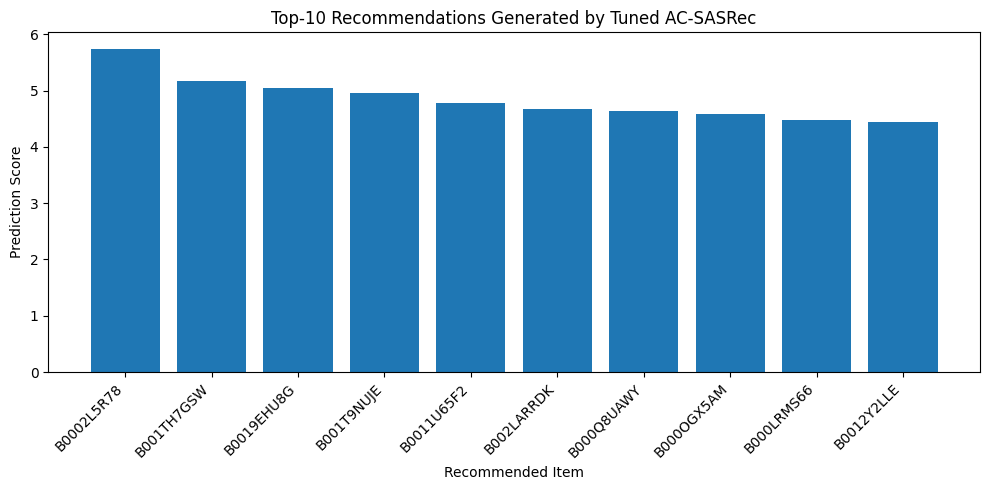

In [94]:
plt.figure(figsize=(10, 5))

plt.bar(
    recommendation_df["Recommended Item"],
    recommendation_df["Prediction Score"]
)

plt.title("Top-10 Recommendations Generated by Tuned AC-SASRec")
plt.xlabel("Recommended Item")
plt.ylabel("Prediction Score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Similarity Heatmap

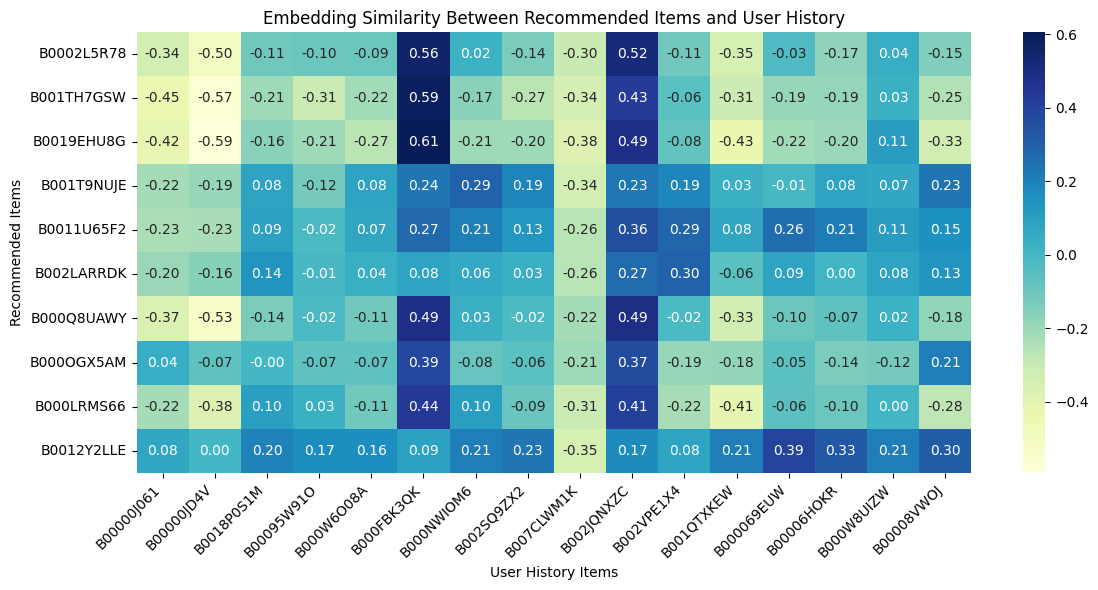

In [97]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

sns.heatmap(
    similarity_matrix,
    cmap="YlGnBu",
    xticklabels=history_items,
    yticklabels=topk_items,
    annot=True,          # Show similarity values
    fmt=".2f"            # Display 2 decimal places
)

plt.title("Embedding Similarity Between Recommended Items and User History")

plt.xlabel("User History Items")
plt.ylabel("Recommended Items")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()

plt.show()